# Solow Model

Pablo Winant

> **Prerequisites**
>
> This tutorial refers to the lecture on the [convergence of
> sequences](../lectures/convergence/).
>
> Also, make sure you went through the [Julia
> Basics](./Julia_Basics.qmd) before.

# Tutorial: Convergence

### Solow Model

A representative agent uses capital $k_t$ to produce $y_t$ using the
following production function:

$$y_t = k_t^{\alpha}$$

He chooses to consume an amount $c_t \in ]0, y_t]$ and invests what
remains:

$$i_t = y_t - c_t$$

He accumulates capital $k_t$ according to:

$$k_{t+1} = \left( 1-\delta \right) k_{t} + i_{t}$$

where $\delta$ is the depreciation rate and $i_t$ is the amount
invested.

The goal of the representative agent is to maximize:

$$\sum_{t\geq 0} \beta^t U(c_t)$$

where $U(x)=\frac{x^{1-\gamma}}{1-\gamma}$ and $\beta<1$ is the discount
factor.

For now, we ignore the objective and assume that the saving rate
$s=\frac{c_t}{y_t}$ is constant over time.

**Create a `NamedTuple` to hold parameter values $\beta=0.96$,
$\delta=0.1$, $\alpha=0.3$, $\gamma=4$.**

``` {julia}
# your code here
```

In [3]:
model = (;α=0.3, β=0.96, γ=4, δ=0.1, s=0.2)

# we add the saving rate to the model


(α = 0.3, β = 0.96, γ = 4, δ = 0.1, s = 0.2)

**Write down the formula of function $f$ such that $k_{t+1}$:
$k_{t+1} = f(k_t)$.**

$k_{t+1} = (1-\delta) k_t + ( s \underbrace{k_t^\alpha}_{\text{production yesterday}} )$

**Define a function `f(k::Float64, p::NamedTuple)::Float64` to represent
$f$ for a given calibration**

``` {julia}
# your code here
```

In [4]:
# function f(k::Float64, p::NamedTuple)::Float64
# end
# we don't have to specify all types
function f(k, p)
    # get α and δ from the model
    (;α, δ, s)=p
    
    i = s*k^α
    K = (1-δ)*k + i
    
end

f (generic function with 1 method)

In [5]:
f(0.2, model)

0.30340677254400195

In [6]:
# see how long it takes to compute
# using macro
@time f(0.2, model)

  0.000006 seconds (1 allocation: 16 bytes)


0.30340677254400195

**Write a function
`simulate(k0::Float64, T::Int, p::NamedTuple)::Vector{Float64}` to
compute the simulation over `T` periods starting from initial capital
level `k0`.**

``` {julia}
# your code here
```

In [7]:
function simulate(k0, T, p)
    # store the result in a vector
    # adjust the size as we go
    kvec = [k0]
    for t ∈ 1:T
        # remember 1:T contains 1 and T
        k = kvec[end] # end: the last element
        # k = kvec[length(kvec)]
        K = f(k, p)
        # append new value to kvec
        push!(kvec, K)
    end
    return kvec
end

simulate (generic function with 1 method)

In [8]:
simulate(0.2, 100, model);

In [9]:
@time simulate(0.2, 100, model);

  0.000016 seconds (7 allocations: 3.008 KiB)


In [10]:
function simulate_noalloc(k0, T, p)
    # store the result in a vector
    kvec = zeros(T+1)
    kvec[1] = k0
    for t ∈ 1:T
        # remember 1:T contains 1 and T
        k = kvec[t] # end: the last element
        # k = kvec[length(kvec)]
        K = f(k, p)
        # append new value to kvec
        kvec[t+1] = K
    end
    return kvec
end

simulate_noalloc (generic function with 1 method)

In [11]:
@time simulate_noalloc(0.2, 100, model);

  0.010058 seconds (13.08 k allocations: 645.609 KiB, 99.68% compilation time)


**Make a nice plot to illustrate the convergence. Do we get convergence
from any initial level of capital?**

``` {julia}
# your code here
```

In [12]:
# import Pkg
# Pkg.activate(".")

In [13]:
using Plots

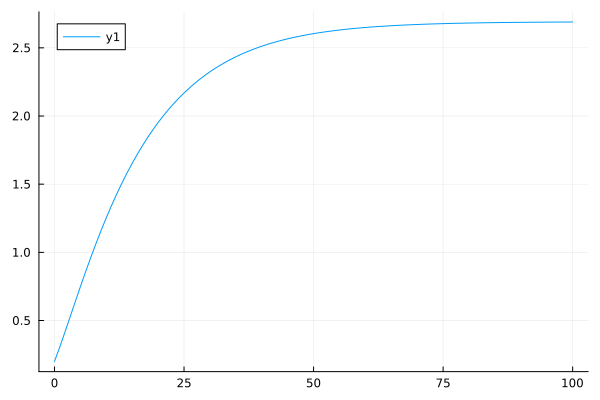

In [14]:
T = 100
tv = 0:T
kv = simulate(0.2, T, model);
plot(tv,kv)

In [15]:
using LaTeXStrings

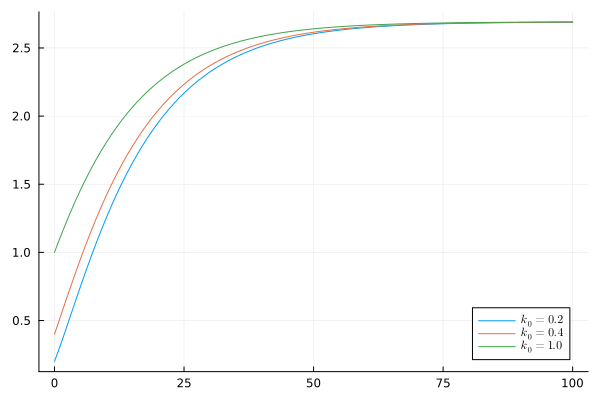

In [16]:
# different starting points
T = 100
tv = 0:T
kv1 = simulate(0.2, T, model);
kv2 = simulate(0.4, T, model);
kv3 = simulate(1.0, T, model);

pl = plot()
# plot!(pl,tv,kv1,label="k_0")
# plot!(pl,tv,kv1,label="\$k_0\$") # escape the dollar sign to avoid string interpolation
# better : use latexstrings library
plot!(pl,tv,kv1,label=L"k_0=0.2") # escape the dollar sign to avoid string interpolation
plot!(pl,tv,kv2,label=L"k_0=0.4")
plot!(pl,tv,kv3,label=L"k_0=1.0")

In [17]:
k_init = [0.2, 0.4, 1.0]
sims = [ simulate(k0,T,model) for k0 in k_init ] # comprehension syntax (same as in python)

3-element Vector{Vector{Float64}}:
 [0.2, 0.30340677254400195, 0.4129080792968781, 0.525003373019628, 0.6373491155565568, 0.7483344417178636, 0.856841626057419, 0.9620988898971137, 1.0635841029776287, 1.1609587708409257  …  2.6873040218731723, 2.6876186883735818, 2.6879113388853018, 2.6881835130861362, 2.6884366430712516, 2.6886720608576273, 2.688891005366757, 2.689094628921639, 2.6892840032916374, 2.6894601253165105]
 [0.4, 0.5119315585864748, 0.6243422704616431, 0.7355508583035453, 0.8443911415579223, 0.9500568333602588, 1.0520006449771238, 1.1498654505051582, 1.2434355847290326, 1.3326014179604118  …  2.687878421679744, 2.6881528990807855, 2.6884081711777905, 2.688645581245582, 2.6888663786779268, 2.68907172553918, 2.689262702660023, 2.689440315308841, 2.6896054984681297, 2.6897591217433026]
 [1.0, 1.1, 1.195801151884219, 1.2872430129191352, 1.3742574618933996, 1.456845771393547, 1.5350611815735393, 1.6089955116075123, 1.6787687913320717, 1.7445211874595348  …  2.689166098397878, 2.

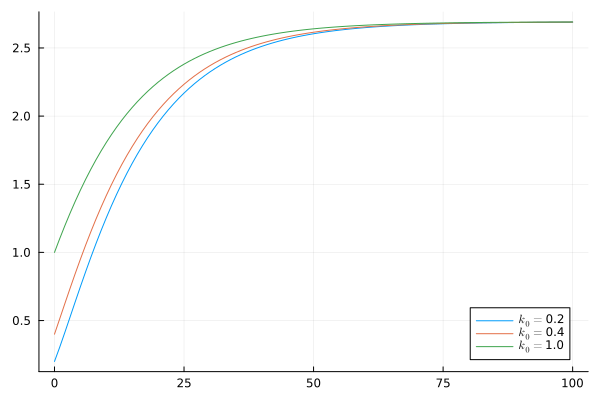

In [18]:
kv3 = simulate(1.0, T, model);
k0 = 0.3
pl = plot()
for sim in sims
    plot!(pl,tv,sim,label=L"k_0=" * "$(sim[1])") # escape the dollar sign to avoid string interpolation
end
pl

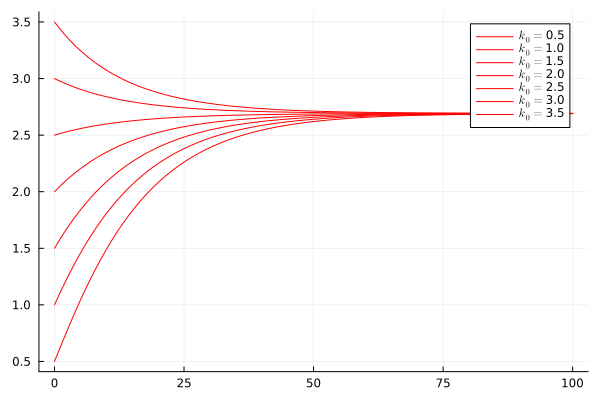

In [19]:
k_init = 0.5: 0.5: 3.5
sims = [ simulate(k0,T,model) for k0 in k_init ] # comprehension syntax (same as in python)
pl = plot()
for (k0, sim) in zip(k_init, sims)
    plot!(pl,tv,sim,label=L"k_0=" * "$(sim[1])", color=:red) # escape the dollar sign to avoid string interpolation
end
pl

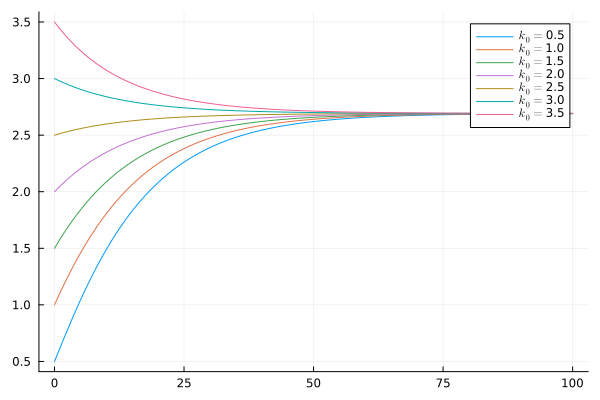

In [20]:
pl = plot()
for (i, sim) in enumerate(sims)
    k0 = k_init[i]
    plot!(pl,tv,sim,label=L"k_0=" * "$(sim[1])") # escape the dollar sign to avoid string interpolation
end
pl

In [21]:
simulation_data = [ (k0,simulate(k0,T,model)) for k0 in k_init ] # comprehension syntax (same as in python)

7-element Vector{Tuple{Float64, Vector{Float64}}}:
 (0.5, [0.5, 0.6124504792712471, 0.7238493517042889, 0.832984403877418, 0.9390166705127817, 1.041375090175603, 1.139684956743144, 1.233717469453318, 1.3233531316502873, 1.40855461086888  …  2.688124717954504, 2.688381961924404, 2.688621205942895, 2.6888437090435797, 2.6890506422578495, 2.68924309475745, 2.6894220795694443, 2.689588538893184, 2.689743349046873, 2.6898873250694084])
 (1.0, [1.0, 1.1, 1.195801151884219, 1.2872430129191352, 1.3742574618933996, 1.456845771393547, 1.5350611815735393, 1.6089955116075123, 1.6787687913320717, 1.7445211874595348  …  2.689166098397878, 2.689350471394512, 2.6895219419408285, 2.689681412713881, 2.689829723270148, 2.6899676544549416, 2.6900959325043807, 2.69021523286128, 2.6903261837248396, 2.6904293693526475])
 (1.5, [1.5, 1.5758693870913711, 1.6475201583781263, 1.7150841935587584, 1.7787098808849766, 1.8385565989758454, 1.8947904001991414, 1.9475806400433953, 1.9970973557459901, 2.0435092411105487

In [22]:
simulation_data = Dict(
    k0=>simulate(k0,T,model)
    for k0 in k_init
) # comprehension syntax for dictionaries

Dict{Float64, Vector{Float64}} with 7 entries:
  2.0 => [2.0, 2.04623, 2.08953, 2.13006, 2.16798, 2.20344, 2.23659, 2.26756, 2…
  0.5 => [0.5, 0.61245, 0.723849, 0.832984, 0.939017, 1.04138, 1.13968, 1.23372…
  3.5 => [3.5, 3.44124, 3.38688, 3.33657, 3.29001, 3.24689, 3.20696, 3.16996, 3…
  1.5 => [1.5, 1.57587, 1.64752, 1.71508, 1.77871, 1.83856, 1.89479, 1.94758, 1…
  2.5 => [2.5, 2.51328, 2.52564, 2.53716, 2.54789, 2.55788, 2.56718, 2.57584, 2…
  1.0 => [1.0, 1.1, 1.1958, 1.28724, 1.37426, 1.45685, 1.53506, 1.609, 1.67877,…
  3.0 => [3.0, 2.97808, 2.95774, 2.93886, 2.92134, 2.90508, 2.88998, 2.87596, 2…

In [23]:
using OrderedCollections
simulation_data = OrderedDict(
    k0=>simulate(k0,T,model)
    for k0 in k_init
) # comprehension syntax for dictionaries

OrderedDict{Float64, Vector{Float64}} with 7 entries:
  0.5 => [0.5, 0.61245, 0.723849, 0.832984, 0.939017, 1.04138, 1.13968, 1.23372…
  1.0 => [1.0, 1.1, 1.1958, 1.28724, 1.37426, 1.45685, 1.53506, 1.609, 1.67877,…
  1.5 => [1.5, 1.57587, 1.64752, 1.71508, 1.77871, 1.83856, 1.89479, 1.94758, 1…
  2.0 => [2.0, 2.04623, 2.08953, 2.13006, 2.16798, 2.20344, 2.23659, 2.26756, 2…
  2.5 => [2.5, 2.51328, 2.52564, 2.53716, 2.54789, 2.55788, 2.56718, 2.57584, 2…
  3.0 => [3.0, 2.97808, 2.95774, 2.93886, 2.92134, 2.90508, 2.88998, 2.87596, 2…
  3.5 => [3.5, 3.44124, 3.38688, 3.33657, 3.29001, 3.24689, 3.20696, 3.16996, 3…

In [24]:
pl = plot()
for (k,v) in each(simulation_data)
    plot!(pl,k,v,label=L"k_0=" * "$(k)") # escape the dollar sign to avoid string interpolation
end
pl

LoadError: UndefVarError: `each` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [25]:
n = 100
"This is a string. You can refer to external values inside: $(n)" # string interpolation

"This is a string. You can refer to external values inside: 100"

In [26]:
# to reparametrize a model

In [27]:
merge(
    model,
    (;s=0.3)
)

(α = 0.3, β = 0.96, γ = 4, δ = 0.1, s = 0.3)

**Suppose you were interested in using `f` to compute the steady-state.
What would you propose to measure convergence speed? To speed-up
convergence? Implement these ideas.**

``` {julia}
# your code here
```

In [47]:
p

LoadError: UndefVarError: `p` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [65]:
function compute_steadystate(k0, T, p ; τ_η=1e-8)

    for t ∈ 1:T
        k1 = f(k0, p)
        η = abs(k1-k0)
        k0 = k1
        if η<τ_η
            # println("Converged in $t iterations")
            return k0
        end
    end

    error("No convergence")
end

compute_steadystate (generic function with 1 method)

In [64]:
@time compute_steadystate(1, 500, model)

Converged in 228 iterations
  0.028495 seconds (15.55 k allocations: 813.156 KiB, 19.92% gc time, 99.51% compilation time)


2.6918002585299976

In [66]:
function compute_steadystate_new(k0, T, p ; τ_η=1e-8, λ=1.0)

    for t ∈ 1:T
        k1 = f(k0, p)
        η = abs(k1-k0)
        k0 = (1-λ)*k0 + λ*k1 # dampening / acceleration scheme
        if η<τ_η
            println("Converged in $t iterations")
            return k0
        end
    end

    error("No convergence")
end

compute_steadystate_new (generic function with 1 method)

In [68]:
@time compute_steadystate_new(1, 500, model)

Converged in 228 iterations
  0.011282 seconds (9.09 k allocations: 457.492 KiB, 99.02% compilation time)


2.6918002585299976

In [72]:
@time compute_steadystate_new(1, 500, model; λ=10)

Converged in 15 iterations
  0.000088 seconds (18 allocations: 640 bytes)


2.6918003470184395

In [ ]:
function compute_steadystate_2(k0, T, p ; τ_η=1e-8)
    # store the result in a vector
    # η = 0.0 # defining \eta puts it in the local scope
    # local η
    for t ∈ 1:T
        k1 = f(k0, p)
        η = abs(k1-k0)
        k0 = k1
        if η<τ_η
            break # stops the for loop
        end
    end
    # println(η) # η defined inside the loop
    # if t>=T
    #     error("No convergence")
    # end
    return k0
end

In [42]:
@time compute_steadystate(1, 100, model)

  0.000012 seconds (1 allocation: 16 bytes)


2.6904293693526475